In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/samriddhi2605/rainfall-flood-prediction/main/data/rainfall_data.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (4188, 19)


,SUBDIVISION,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,JF,MAM,JJAS,OND
0,Andaman & Nicobar Islands,1901,49.2,87.1,29.2,2.3,528.8,517.5,365.1,481.1,332.6,388.5,558.2,33.6,3373.2,136.3,560.3,1696.3,980.3
1,Andaman & Nicobar Islands,1902,0.0,159.8,12.2,0.0,446.1,537.1,228.9,753.7,666.2,197.2,359.0,160.5,3520.7,159.8,458.3,2185.9,716.7
2,Andaman & Nicobar Islands,1903,12.7,144.0,0.0,1.0,235.1,479.9,728.4,326.7,339.0,181.2,284.4,225.0,2957.4,156.7,236.1,1874.0,690.6
3,Andaman & Nicobar Islands,1904,9.4,14.7,0.0,202.4,304.5,495.1,502.0,160.1,820.4,222.2,308.7,40.1,3079.6,24.1,506.9,1977.6,571.0
4,Andaman & Nicobar Islands,1905,1.3,0.0,3.3,26.9,279.5,628.7,368.7,330.5,297.0,260.7,25.4,344.7,2566.7,1.3,309.7,1624.9,630.8


In [2]:
# Filter the dataset for Kerala
kerala = df[df["SUBDIVISION"].str.contains("Kerala", case=False, na=False)].copy()

print("Kerala dataset shape:", kerala.shape)
print("\nYears covered:")
print(kerala["YEAR"].min(), "to", kerala["YEAR"].max())

kerala.head()

Kerala dataset shape: (117, 19)

Years covered:
1901 to 2017


,SUBDIVISION,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,JF,MAM,JJAS,OND
3955,Kerala,1901,28.7,44.7,51.6,160.0,174.7,824.6,743.0,357.5,197.7,266.9,350.8,48.4,3248.6,73.4,386.2,2122.8,666.1
3956,Kerala,1902,6.7,2.6,57.3,83.9,134.5,390.9,1205.0,315.8,491.6,358.4,158.3,121.5,3326.6,9.3,275.7,2403.4,638.2
3957,Kerala,1903,3.2,18.6,3.1,83.6,249.7,558.6,1022.5,420.2,341.8,354.1,157.0,59.0,3271.2,21.7,336.3,2343.0,570.1
3958,Kerala,1904,23.7,3.0,32.2,71.5,235.7,1098.2,725.5,351.8,222.7,328.1,33.9,3.3,3129.7,26.7,339.4,2398.2,365.3
3959,Kerala,1905,1.2,22.3,9.4,105.9,263.3,850.2,520.5,293.6,217.2,383.5,74.4,0.2,2741.6,23.4,378.5,1881.5,458.1


In [7]:


# Calculate the 75th percentile of Kerala's annual rainfall
rainfall_threshold = kerala["ANNUAL"].quantile(0.75)

print("Rainfall threshold for high-risk years:")
print(round(rainfall_threshold, 2), "mm")

# 1 = High rainfall / higher flood-risk year
# 0 = Normal rainfall year
kerala["Flood_Risk"] = (
    kerala["ANNUAL"] >= rainfall_threshold
).astype(int)

# Display the result
print("\nFlood-risk distribution:")
print(kerala["Flood_Risk"].value_counts())

print("\nPercentage distribution:")
print(
    (kerala["Flood_Risk"].value_counts(normalize=True) * 100).round(2)
)

kerala[["YEAR", "ANNUAL", "Flood_Risk"]].head(10)

Rainfall threshold for high-risk years:
3151.5 mm

Flood-risk distribution:
Flood_Risk
0    87
1    30
Name: count, dtype: int64

Percentage distribution:
Flood_Risk
0    74.36
1    25.64
Name: proportion, dtype: float64


,YEAR,ANNUAL,Flood_Risk
3955,1901,3248.6,1
3956,1902,3326.6,1
3957,1903,3271.2,1
3958,1904,3129.7,0
3959,1905,2741.6,0
3960,1906,2708.0,0
3961,1907,3671.1,1
3962,1908,2648.3,0
3963,1909,3050.2,0
3964,1910,2848.6,0


In [4]:


# Monthly rainfall columns
monthly_features = [
    "JAN", "FEB", "MAR", "APR", "MAY", "JUN",
    "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"
]

# Create feature matrix (X)
X = kerala[monthly_features].copy()

# Create target variable (y)
y = kerala["Flood_Risk"].copy()

print("Features used:")
print(monthly_features)

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nMissing values:")
print(X.isnull().sum())

print("\nFirst 5 feature rows:")
display(X.head())

print("\nFirst 5 target values:")
display(y.head())

Features used:
['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']

Feature matrix shape: (117, 12)
Target shape: (117,)

Missing values:
JAN    0
FEB    0
MAR    0
APR    0
MAY    0
JUN    0
JUL    0
AUG    0
SEP    0
OCT    0
NOV    0
DEC    0
dtype: int64

First 5 feature rows:


,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC
3955,28.7,44.7,51.6,160.0,174.7,824.6,743.0,357.5,197.7,266.9,350.8,48.4
3956,6.7,2.6,57.3,83.9,134.5,390.9,1205.0,315.8,491.6,358.4,158.3,121.5
3957,3.2,18.6,3.1,83.6,249.7,558.6,1022.5,420.2,341.8,354.1,157.0,59.0
3958,23.7,3.0,32.2,71.5,235.7,1098.2,725.5,351.8,222.7,328.1,33.9,3.3
3959,1.2,22.3,9.4,105.9,263.3,850.2,520.5,293.6,217.2,383.5,74.4,0.2



First 5 target values:


,Flood_Risk
3955,1
3956,1
3957,1
3958,0
3959,0


In [5]:


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data: (93, 12)
Testing data: (24, 12)

Training target distribution:
Flood_Risk
0    69
1    24
Name: count, dtype: int64

Testing target distribution:
Flood_Risk
0    18
1     6
Name: count, dtype: int64


In [6]:


from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    class_weight="balanced"
)


rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [8]:


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Random Forest Performance")
print("=" * 35)
print(f"Accuracy  : {accuracy:.2%}")
print(f"Precision : {precision:.2%}")
print(f"Recall    : {recall:.2%}")
print(f"F1-Score  : {f1:.2%}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Random Forest Performance
Accuracy  : 79.17%
Precision : 100.00%
Recall    : 16.67%
F1-Score  : 28.57%

Classification Report:
              precision    recall  f1-score   support

           0       0.78      1.00      0.88        18
           1       1.00      0.17      0.29         6

    accuracy                           0.79        24
   macro avg       0.89      0.58      0.58        24
weighted avg       0.84      0.79      0.73        24

Confusion Matrix:
[[18  0]
 [ 5  1]]


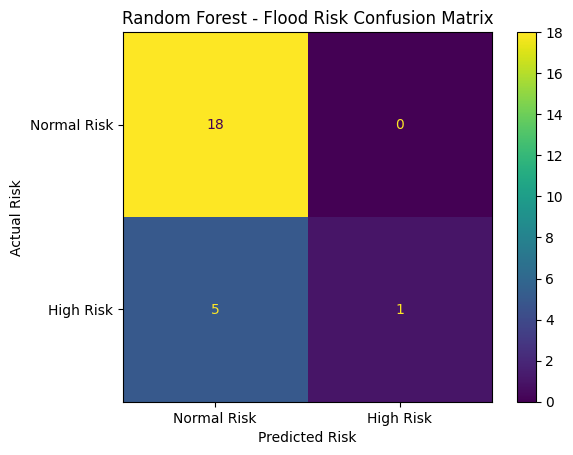

In [9]:


import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal Risk", "High Risk"]
)

disp.plot()
plt.title("Random Forest - Flood Risk Confusion Matrix")
plt.xlabel("Predicted Risk")
plt.ylabel("Actual Risk")
plt.show()

Rainfall feature importance:


,Month,Importance
6,JUL,0.258562
5,JUN,0.119693
7,AUG,0.081119
10,NOV,0.077865
9,OCT,0.077137
4,MAY,0.064493
0,JAN,0.063969
8,SEP,0.058840
2,MAR,0.057813
11,DEC,0.055289


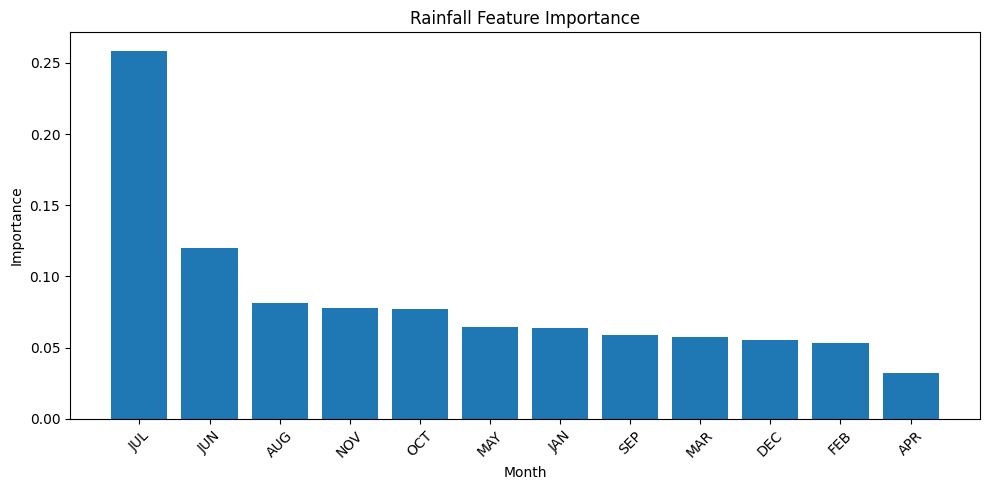

In [10]:


import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from the Random Forest
importance = pd.DataFrame({
    "Month": monthly_features,
    "Importance": rf_model.feature_importances_
})

# Sort from most to least important
importance = importance.sort_values(
    "Importance",
    ascending=False
)

print("Rainfall feature importance:")
display(importance)


plt.figure(figsize=(10, 5))

plt.bar(
    importance["Month"],
    importance["Importance"]
)

plt.title("Rainfall Feature Importance")
plt.xlabel("Month")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
# ==========================================
# FLOOD RISK PREDICTION TOOL
# ==========================================

print("🌧️ Rainfall-Based Flood Risk Predictor")
print("=" * 45)

print("Enter the monthly rainfall values in mm.")
print("Press Enter after entering each value.\n")

months = [
    "JAN", "FEB", "MAR", "APR", "MAY", "JUN",
    "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"
]

user_rainfall = []

for month in months:
    while True:
        try:
            value = float(input(f"{month} rainfall (mm): "))
            if value < 0:
                print("Please enter a non-negative value.")
                continue
            user_rainfall.append(value)
            break
        except ValueError:
            print("Please enter a valid number.")

# Convert input into DataFrame
user_data = pd.DataFrame([user_rainfall], columns=months)

# Predict flood risk
prediction = rf_model.predict(user_data)[0]

# Probability of high-risk classification
probability = rf_model.predict_proba(user_data)[0][1]

print("\n" + "=" * 45)
print("PREDICTION RESULT")
print("=" * 45)

if prediction == 1:
    print("⚠️ HIGH FLOOD RISK")
else:
    print("✅ NORMAL FLOOD RISK")

print(f"High-risk probability: {probability:.2%}")

🌧️ Rainfall-Based Flood Risk Predictor
Enter the monthly rainfall values in mm.
Press Enter after entering each value.

JAN rainfall (mm): 50
FEB rainfall (mm): 60
MAR rainfall (mm): 70
APR rainfall (mm): 200
MAY rainfall (mm): 250
JUN rainfall (mm): 500
JUL rainfall (mm): 1000
AUG rainfall (mm): 800
SEP rainfall (mm): 400
OCT rainfall (mm): 200
NOV rainfall (mm): 100
DEC rainfall (mm): 50

PREDICTION RESULT
⚠️ HIGH FLOOD RISK
High-risk probability: 50.57%
